# Random Forest en Cancer_Data: sin PCA vs con PCA

En este notebook aplicamos **Random Forest** al dataset **Cancer_Data.csv** en dos escenarios:

1. Sin PCA (usamos todas las variables originales).
2. Con PCA (reducimos variables a componentes principales).

El objetivo es comparar el rendimiento y discutir ventajas y limitaciones.

---

## Objetivos

- Entrenar un Random Forest sin reduccion de dimensiones.
- Aplicar PCA y elegir un numero adecuado de componentes.
- Entrenar un Random Forest sobre las componentes seleccionadas.
- Comparar metricas y tomar una conclusion.

# 1. Cargar librerias y configurar entorno

En esta parte importamos las librerias necesarias para:

- Manipular datos.
- Entrenar modelos.
- Aplicar PCA.
- Evaluar metricas.
- Graficar resultados.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# 2. Cargar y explorar el dataset de cancer

Cargamos el archivo **Cancer_Data.csv** y revisamos:

- Dimensiones.
- Primeras filas.
- Tipos de datos.
- Porcentaje de valores faltantes.

In [54]:
data_path = Path("..") / "Cancer_Data.csv"

if not data_path.exists():
    raise FileNotFoundError(f"No se encontro el archivo: {data_path.resolve()}")

df = pd.read_csv(data_path)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (569, 32)


,id,"""diagnosis""","""radius_mean""","""texture_mean""","""perimeter_mean""","""area_mean""","""smoothness_mean""","""compactness_mean""","""concavity_mean""","""concave points_mean""","""symmetry_mean""","""fractal_dimension_mean""","""radius_se""","""texture_se""","""perimeter_se""","""area_se""","""smoothness_se""","""compactness_se""","""concavity_se""","""concave points_se""","""symmetry_se""","""fractal_dimension_se""","""radius_worst""","""texture_worst""","""perimeter_worst""","""area_worst""","""smoothness_worst""","""compactness_worst""","""concavity_worst""","""concave points_worst""","""symmetry_worst""","""fractal_dimension_worst"""
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          569 non-null    int64  
 1    "diagnosis"                569 non-null    str    
 2    "radius_mean"              569 non-null    float64
 3    "texture_mean"             569 non-null    float64
 4    "perimeter_mean"           569 non-null    float64
 5    "area_mean"                569 non-null    float64
 6    "smoothness_mean"          569 non-null    float64
 7    "compactness_mean"         569 non-null    float64
 8    "concavity_mean"           569 non-null    float64
 9    "concave points_mean"      569 non-null    float64
 10   "symmetry_mean"            569 non-null    float64
 11   "fractal_dimension_mean"   569 non-null    float64
 12   "radius_se"                569 non-null    float64
 13   "texture_se"               569 non-null    fl

In [56]:
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
}).sort_values("faltantes", ascending=False)

faltantes.head(10)

,faltantes,porcentaje
id,0,0.0
"""diagnosis""",0,0.0
"""radius_mean""",0,0.0
"""texture_mean""",0,0.0
"""perimeter_mean""",0,0.0
"""area_mean""",0,0.0
"""smoothness_mean""",0,0.0
"""compactness_mean""",0,0.0
"""concavity_mean""",0,0.0
"""concave points_mean""",0,0.0


# 3. Preparar variables (limpieza, objetivo y separacion X/y)

Pasos clave:

- Eliminar columnas que no aportan (`id` o columnas vacias).
- Convertir `diagnosis` a binaria: **M=1**, **B=0**.
- Asegurar que todo sea numerico.
- Separar X e y.

In [57]:
df_limpio = df.copy()

# Normalizar nombres de columnas (quitar espacios, comillas y caracteres invisibles)
col_originales = df_limpio.columns.astype(str)
col_limpias = (
    col_originales
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.strip("\"")
    .str.strip("'")
)

def normalizar_col(nombre):
    return (
        str(nombre)
        .replace("\ufeff", "")
        .strip()
        .strip("\"")
        .strip("'")
        .lower()
        .replace(" ", "")
        .replace("_", "")
    )

mapa_nombres = {}
for original, limpia in zip(col_originales, col_limpias):
    clave = normalizar_col(limpia)
    if clave == "diagnosis":
        mapa_nombres[original] = "diagnosis"
    elif clave == "id":
        mapa_nombres[original] = "id"
    else:
        mapa_nombres[original] = limpia

df_limpio = df_limpio.rename(columns=mapa_nombres)

# Eliminar columnas totalmente vacias
columnas_vacias = df_limpio.columns[df_limpio.isna().all()].tolist()
if columnas_vacias:
    df_limpio = df_limpio.drop(columns=columnas_vacias)

# Eliminar columnas tipo "Unnamed" si existen
columnas_unnamed = [col for col in df_limpio.columns if col.lower().startswith("unnamed")]
if columnas_unnamed:
    df_limpio = df_limpio.drop(columns=columnas_unnamed)

# Eliminar id si existe
if "id" in df_limpio.columns:
    df_limpio = df_limpio.drop(columns=["id"])

# Variable objetivo
if "diagnosis" not in df_limpio.columns:
    raise ValueError("No se encontro la columna diagnosis en el dataset")

df_limpio["diagnosis"] = df_limpio["diagnosis"].astype(str).str.strip().map({"M": 1, "B": 0})

# Convertir a numerico e imputar con mediana si hay faltantes
for col in df_limpio.columns:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

df_limpio = df_limpio.fillna(df_limpio.median(numeric_only=True))

X = df_limpio.drop(columns=["diagnosis"])
y = df_limpio["diagnosis"]

print("X:", X.shape)
print("y:", y.shape)
X.head()

X: (569, 30)
y: (569,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 4. Division train/test

Usamos una separacion 70/30 con **estratificacion**, para conservar la proporcion de clases en entrenamiento y prueba.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (398, 30)
Test: (171, 30)


# 5. Baseline: Random Forest sin PCA

Entrenamos un Random Forest con parametros razonables.

- `n_estimators`: numero de arboles.
- `random_state`: reproducibilidad.

In [59]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

# 6. Evaluacion del modelo sin PCA

Calculamos metricas y revisamos la matriz de confusion para entender errores por clase.

In [60]:
def evaluar_clasificacion(y_real, y_pred):
    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred),
        "recall": recall_score(y_real, y_pred),
        "f1": f1_score(y_real, y_pred)
    }

metricas_base = evaluar_clasificacion(y_test, y_pred_base)

pd.DataFrame([metricas_base], index=["Random Forest sin PCA"])

,accuracy,precision,recall,f1
Random Forest sin PCA,0.97076,1.0,0.921875,0.95935


              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98       107
     Maligno       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



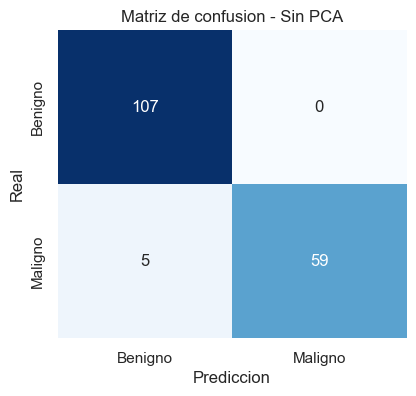

In [61]:
print(classification_report(y_test, y_pred_base, target_names=["Benigno", "Maligno"]))

cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Benigno", "Maligno"],
            yticklabels=["Benigno", "Maligno"])
plt.title("Matriz de confusion - Sin PCA")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

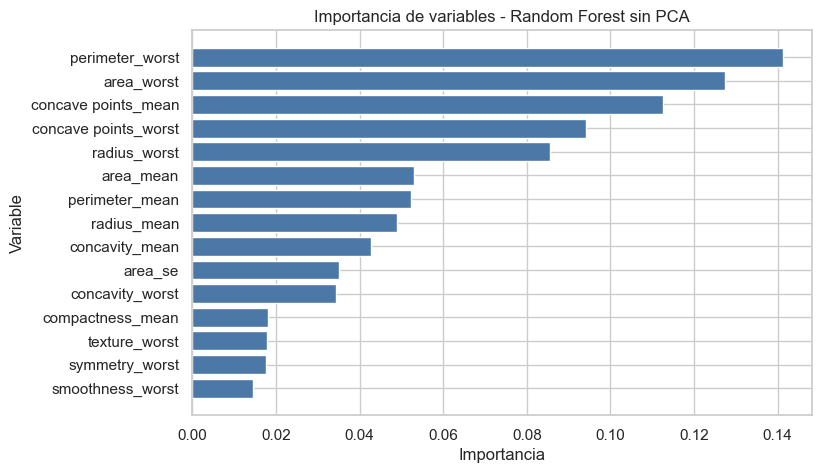

In [62]:
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": rf_base.feature_importances_
}).sort_values("importancia", ascending=False)

top_importancias = importancias.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_importancias["variable"], top_importancias["importancia"], color="#4C78A8")
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Random Forest sin PCA")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### Sensibilidad a numero de arboles (n_estimators)

Probamos distintos valores de `n_estimators` para ver estabilidad del modelo sin PCA y si el rendimiento se estabiliza.

In [63]:
valores_estimadores = [10, 50, 100, 200, 500]
resultados_estimadores = []

for n in valores_estimadores:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    resultados_estimadores.append({
        "n_estimators": n,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

df_estimadores = pd.DataFrame(resultados_estimadores)
df_estimadores

,n_estimators,accuracy,precision,recall,f1
0,10,0.947368,1.0,0.859375,0.92437
1,50,0.964912,1.0,0.906250,0.95082
2,100,0.964912,1.0,0.906250,0.95082
3,200,0.970760,1.0,0.921875,0.95935
4,500,0.970760,1.0,0.921875,0.95935


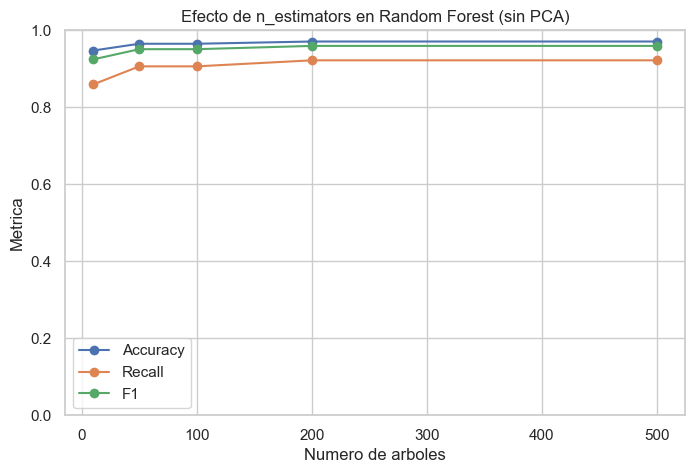

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(df_estimadores["n_estimators"], df_estimadores["accuracy"], marker="o", label="Accuracy")
plt.plot(df_estimadores["n_estimators"], df_estimadores["recall"], marker="o", label="Recall")
plt.plot(df_estimadores["n_estimators"], df_estimadores["f1"], marker="o", label="F1")
plt.title("Efecto de n_estimators en Random Forest (sin PCA)")
plt.xlabel("Numero de arboles")
plt.ylabel("Metrica")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

## Analisis y conclusiones: Random Forest sin PCA

**Lectura del rendimiento**
- Al usar todas las variables originales, el modelo aprovecha la informacion completa del dataset, incluyendo relaciones no lineales entre variables.
- Si las metricas (accuracy, precision, recall, f1) son altas y balanceadas, significa que el modelo esta clasificando bien tanto benignos como malignos.
- La matriz de confusion permite ver el tipo de error mas delicado: un **falso negativo** (maligno clasificado como benigno).

**Analisis con graficas**
- **Importancia de variables:** el grafico muestra que pocas variables concentran buena parte del poder predictivo, lo cual es comun en datasets clinicos.
- **Sensibilidad a `n_estimators`:** si las curvas se estabilizan a partir de cierto numero de arboles, significa que agregar mas arboles da mejoras marginales.

**Interpretacion didactica**
- Random Forest combina muchos arboles y reduce el sobreajuste de un arbol individual.
- En este escenario, las variables originales mantienen interpretabilidad directa: cada variable es una medicion clinica real.
- Si el modelo sin PCA obtiene resultados superiores, es una senal de que la informacion detallada ayuda mas que la reduccion de dimensiones.

**Conclusiones clave**
- El modelo sin PCA suele maximizar el rendimiento porque no pierde informacion en la transformacion.
- Es ideal cuando el objetivo es **maxima precision diagnostica** y no se tiene problema con muchas variables.
- La lectura de la matriz de confusion es fundamental para decidir si el modelo es aceptable en un contexto medico.

# 7. Escalado y PCA: seleccion de componentes

PCA requiere escalado. Ajustamos PCA completo para observar la **varianza explicada acumulada** y elegir un numero de componentes.

Usaremos un umbral del **95%** como referencia.

In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_full = PCA()
pca_full.fit(X_train_scaled)

varianza = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

umbral = 0.95
k = int(np.argmax(varianza_acum >= umbral) + 1)

print("Componentes seleccionados (k):", k)
print("Varianza acumulada en k:", round(varianza_acum[k-1], 4))

Componentes seleccionados (k): 10
Varianza acumulada en k: 0.9521


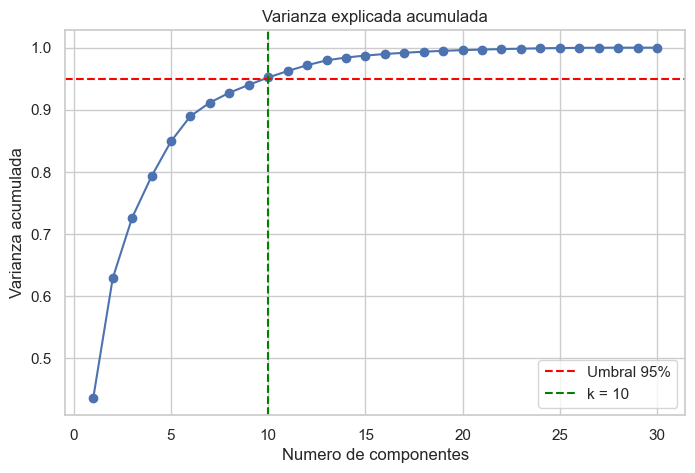

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acum) + 1), varianza_acum, marker="o")
plt.axhline(umbral, color="red", linestyle="--", label=f"Umbral {int(umbral*100)}%")
plt.axvline(k, color="green", linestyle="--", label=f"k = {k}")
plt.title("Varianza explicada acumulada")
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid(True)
plt.show()

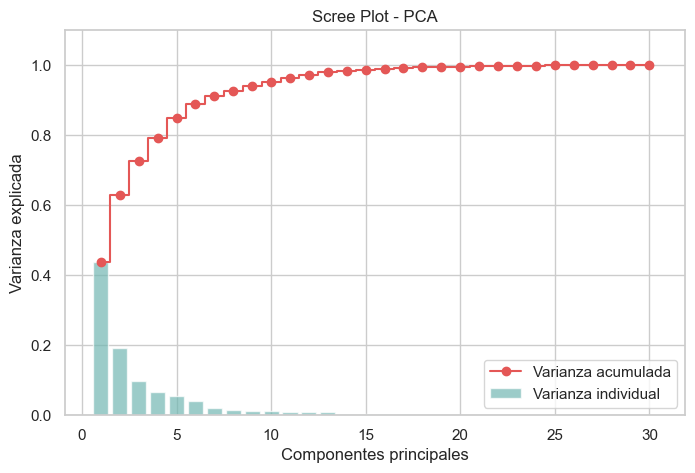

In [67]:
explained = varianza
cumulative = varianza_acum

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained) + 1), explained, alpha=0.7, label="Varianza individual", color="#72B7B2")
plt.step(range(1, len(cumulative) + 1), cumulative, where="mid", label="Varianza acumulada", color="#E45756", marker="o")
plt.title("Scree Plot - PCA")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)
plt.show()

C:\Users\andru\AppData\Local\Temp\ipykernel_27088\4251057229.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loadings.loc[top_pc1, "PC1"], y=top_pc1, ax=axes[0], palette="viridis")
C:\Users\andru\AppData\Local\Temp\ipykernel_27088\4251057229.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loadings.loc[top_pc2, "PC2"], y=top_pc2, ax=axes[1], palette="viridis")


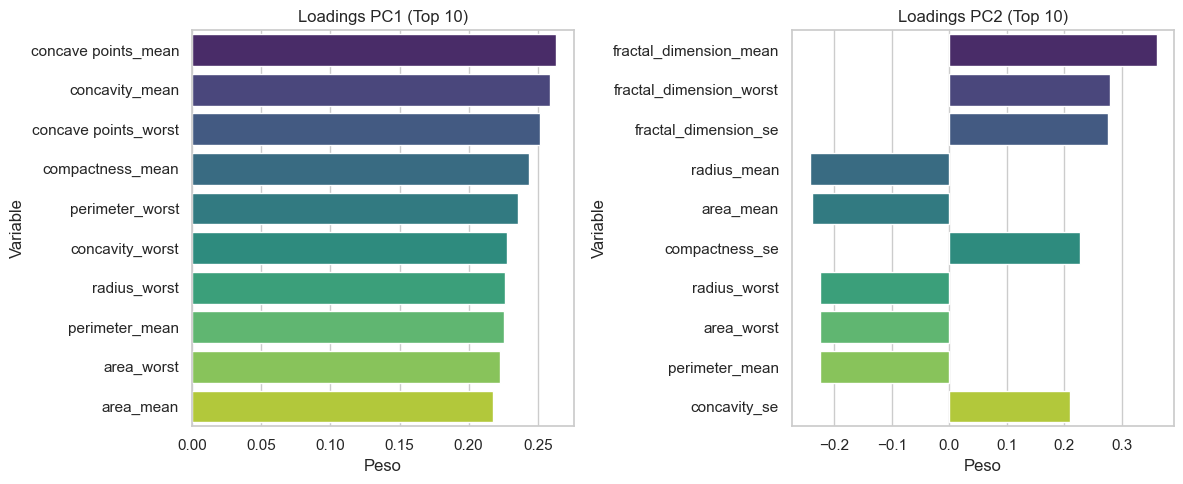

In [68]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_full.components_.shape[0])],
    index=X.columns
)

top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=loadings.loc[top_pc1, "PC1"], y=top_pc1, ax=axes[0], palette="viridis")
axes[0].set_title("Loadings PC1 (Top 10)")
axes[0].set_xlabel("Peso")
axes[0].set_ylabel("Variable")

sns.barplot(x=loadings.loc[top_pc2, "PC2"], y=top_pc2, ax=axes[1], palette="viridis")
axes[1].set_title("Loadings PC2 (Top 10)")
axes[1].set_xlabel("Peso")
axes[1].set_ylabel("Variable")

plt.tight_layout()
plt.show()

# 8. Random Forest con PCA

Transformamos los datos a **k componentes** y entrenamos un Random Forest con los mismos parametros base.

In [69]:
pca = PCA(n_components=k)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

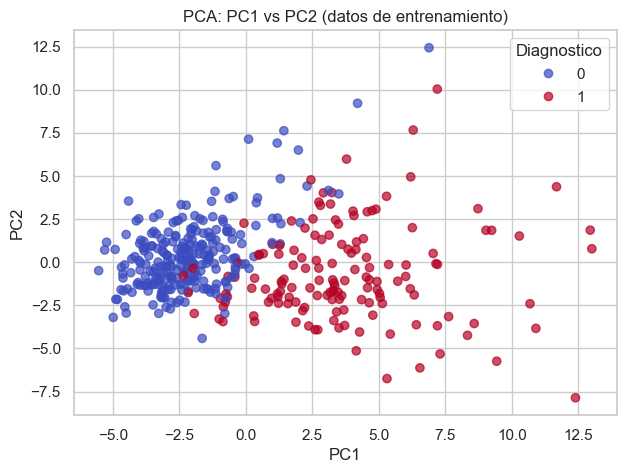

In [70]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.7
)
plt.title("PCA: PC1 vs PC2 (datos de entrenamiento)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Diagnostico")
plt.grid(True)
plt.show()

# 9. Evaluacion del modelo con PCA

Repetimos las metricas y la matriz de confusion para comparar con el modelo sin PCA.

In [71]:
metricas_pca = evaluar_clasificacion(y_test, y_pred_pca)

pd.DataFrame([metricas_pca], index=["Random Forest con PCA"])

,accuracy,precision,recall,f1
Random Forest con PCA,0.953216,0.966667,0.90625,0.935484


              precision    recall  f1-score   support

     Benigno       0.95      0.98      0.96       107
     Maligno       0.97      0.91      0.94        64

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



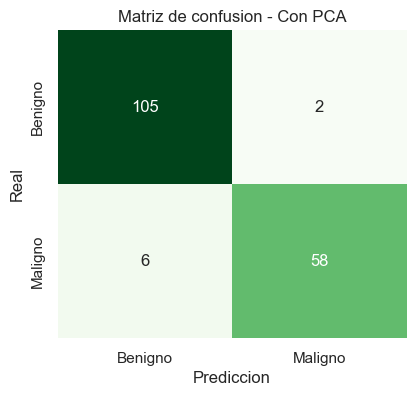

In [72]:
print(classification_report(y_test, y_pred_pca, target_names=["Benigno", "Maligno"]))

cm_pca = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_pca, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Benigno", "Maligno"],
            yticklabels=["Benigno", "Maligno"])
plt.title("Matriz de confusion - Con PCA")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

## Analisis y conclusiones: Random Forest con PCA

**Lectura del rendimiento**
- Aqui trabajamos con componentes principales que resumen la varianza de los datos.
- Si las metricas se mantienen cercanas al modelo sin PCA, significa que PCA conservo la informacion clave.
- Si las metricas bajan, indica que la reduccion elimino senales utiles para clasificar.

**Analisis con graficas**
- **Scree plot y varianza acumulada:** ayudan a justificar el numero de componentes elegido; si la curva se aplana, mas componentes aportan poco.
- **Loadings (PC1 y PC2):** muestran que variables originales dominan cada componente, lo cual da una lectura de que tipo de informacion se esta conservando.
- **Dispersión PC1 vs PC2:** permite ver si las clases se separan visualmente en el espacio reducido; buena separacion suele anticipar buen rendimiento.

**Interpretacion didactica**
- PCA transforma variables originales en nuevas variables (componentes) que no son interpretables clinicamente de forma directa.
- La ventaja principal es reducir dimensionalidad y ruido, lo cual puede ayudar a modelos sensibles al sobreajuste.
- En Random Forest, que ya es robusto, la ganancia de PCA puede ser menor, pero aun sirve para simplificar el problema.

**Conclusiones clave**
- El modelo con PCA es adecuado cuando se busca simplificar el conjunto de variables sin perder mucho desempeno.
- Si el numero de componentes es razonable (por ejemplo 90% a 95% de varianza), la perdida de informacion suele ser controlada.
- La decision entre usar PCA o no depende del equilibrio entre **rendimiento** y **simplicidad**.

# 10. Comparacion final de resultados (metricas y breve analisis)

Construimos una tabla y un grafico para comparar el rendimiento entre:

- Random Forest sin PCA.
- Random Forest con PCA.

Luego discutimos cual conviene y por que.

In [73]:
comparacion = pd.DataFrame([
    {"modelo": "Random Forest sin PCA", **metricas_base},
    {"modelo": "Random Forest con PCA", **metricas_pca}
])

comparacion

,modelo,accuracy,precision,recall,f1
0,Random Forest sin PCA,0.970760,1.000000,0.921875,0.959350
1,Random Forest con PCA,0.953216,0.966667,0.906250,0.935484


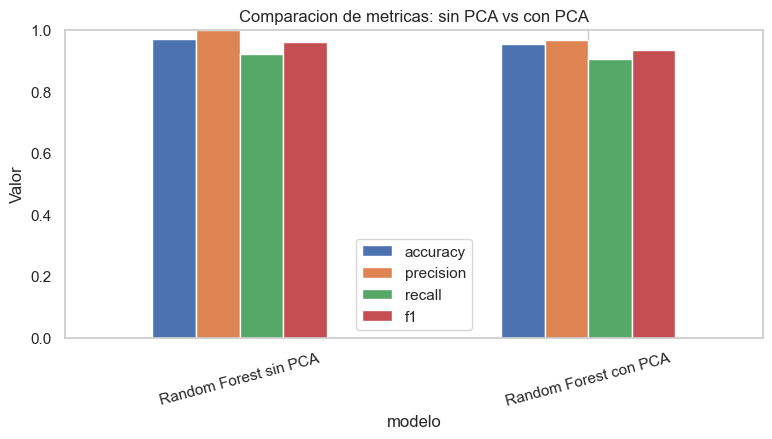

In [74]:
metricas_cols = ["accuracy", "precision", "recall", "f1"]

comparacion.set_index("modelo")[metricas_cols].plot(kind="bar", figsize=(9, 4))
plt.title("Comparacion de metricas: sin PCA vs con PCA")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

## Comparacion final: sin PCA vs con PCA

**Diferencias puntuales**
- **Entrada del modelo:**
  - Sin PCA: variables clinicas originales (interpretables).
  - Con PCA: componentes sinteticas (menos interpretables).
- **Desempeno esperado:**
  - Sin PCA: suele ser igual o mejor si las variables aportan informacion directa.
  - Con PCA: puede bajar un poco si se pierde senal, o mantenerse si la varianza retenida es alta.
- **Complejidad y mantenimiento:**
  - Sin PCA: mas variables, mas costo de analisis, pero mayor transparencia.
  - Con PCA: menos variables, mas compacto, pero menos explicable.

**Analisis general con apoyo grafico**
- El grafico de **n_estimators** indica si el modelo sin PCA ya esta estable con 200 arboles o si aun gana al subir el numero.
- El **scree plot** y los **loadings** explican cuanta informacion retuvo PCA y que variables influyen mas en los componentes.
- El scatter **PC1 vs PC2** muestra si existe separacion visible entre benignos y malignos en el espacio reducido.

**Conclusiones completas**
- **Random Forest sin PCA** es la mejor opcion cuando se busca el mayor rendimiento posible y se requiere interpretabilidad directa en variables clinicas.
- **Random Forest con PCA** es util cuando se necesita simplificar el modelo o reducir dimensionalidad, aceptando cierta perdida de interpretabilidad.
- La decision final debe basarse en el equilibrio entre:
  - calidad de clasificacion,
  - riesgo de errores clinicos,
  - facilidad para explicar el modelo,
  - costo computacional.

En resumen: si el rendimiento del modelo sin PCA es superior, se recomienda mantener las variables originales. Si ambos rendimientos son similares, PCA es una alternativa valida para simplificar el modelo sin sacrificar demasiado desempeno.